In [28]:
import polars as pl
import os 
from pathlib import Path
import numpy as np
paul_data_dir = Path('/home/vincent/Senior thesis work/blechRNN-master/data/paul_data/spikes/spikes/')
# paul states: 
#The zipped folder has one file per trial with spikes sorted in two
#columns, first column are times, second column neuron IDs.

In [20]:
paul_data_dir.glob('*.dat')

<generator object Path.glob at 0x7affad5ba9b0>

In [39]:
# now extracting the data from the .dat files
# note, having to downgrade numpy sucks a whole lot
frames = []
for file in sorted(paul_data_dir.glob('*.dat')):
    dat = (
        pl.read_csv(file, has_header=False, separator='\x1f', new_columns=['raw'])  # sep never appears -> whole line per row
        .with_columns(pl.col('raw').str.extract_all(r'\S+').alias('tok'))
        .select(
            pl.col('tok').list.get(0).cast(pl.Float64).alias('spk_time'),
            pl.col('tok').list.get(1).cast(pl.Float64).round().cast(pl.Int64).alias('neuron'),
        )
        .with_columns(pl.lit(file.stem).alias('trial')) # note: ai knew the minutae of the syntax here to get it right 
    )
    frames.append(dat)
# get the wrote trial numers individually: 
df = pl.concat(frames, how='vertical')
df = df.with_columns(pl.col('trial').str.extract(r'trial_(\d+)$', 1).cast(pl.Int64))
bin_size = 0.025  # 25 ms — your times are in seconds
#df = df.with_columns((pl.col('spk_time') // bin_size).cast(pl.Int64).alias('bin'))

df

spk_time,neuron,trial
f64,i64,i64
0.0003,15,1
0.0011,21,1
0.0037,16,1
0.0049,20,1
0.0087,14,1
…,…,…
1.958,6,9
1.9654,5,9
1.976,1,9


In [46]:
df['neuron'].unique()

neuron
i64
1
2
3
4
5
…
26
27
28


/tmp/ipykernel_690259/1760079051.py:17: DeprecationWarning: The default coalesce behavior of left join will change to `False` in the next breaking release. Pass `coalesce=True` to keep the current behavior and silence this warning.
  .join(counts, on='bin', how='left')


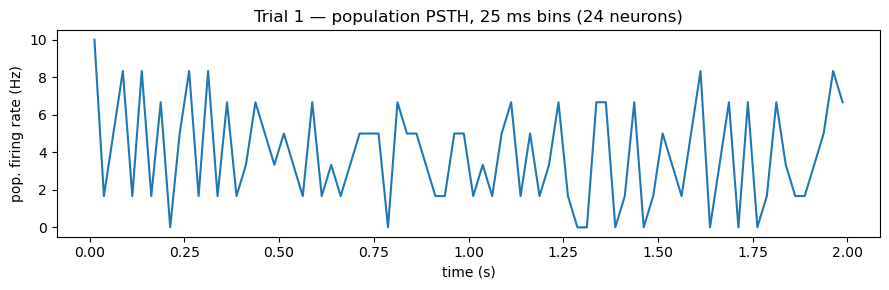

In [62]:
import matplotlib.pyplot as plt
import polars as pl

bin_size = 0.025 # 25 ms — change this one number to rebin

t1 = df.filter(pl.col('trial') == 4)
n_neurons = t1['neuron'].n_unique()
n_bins = int(t1['spk_time'].max() / bin_size) + 1

counts = (
    t1.with_columns((pl.col('spk_time') // bin_size).cast(pl.Int64).alias('bin'))
      .group_by('bin').agg(pl.len().alias('c'))
)

psth = (
    pl.DataFrame({'bin': range(n_bins)})                 # full bin grid → fills the gaps
      .join(counts, on='bin', how='left')
      .with_columns(pl.col('c').fill_null(0))
      .sort('bin')
      .with_columns(
          ((pl.col('bin') + 0.5) * bin_size).alias('t'),         # bin center, seconds
          (pl.col('c') / (bin_size * n_neurons)).alias('rate'),  # pop-avg rate, Hz
      )
)

plt.figure(figsize=(9, 3))
plt.plot(psth['t'].to_list(), psth['rate'].to_list())
plt.xlabel('time (s)')
plt.ylabel('pop. firing rate (Hz)')
plt.title(f'Trial 1 — population PSTH, {int(bin_size*1000)} ms bins ({n_neurons} neurons)')
plt.tight_layout()
plt.show()

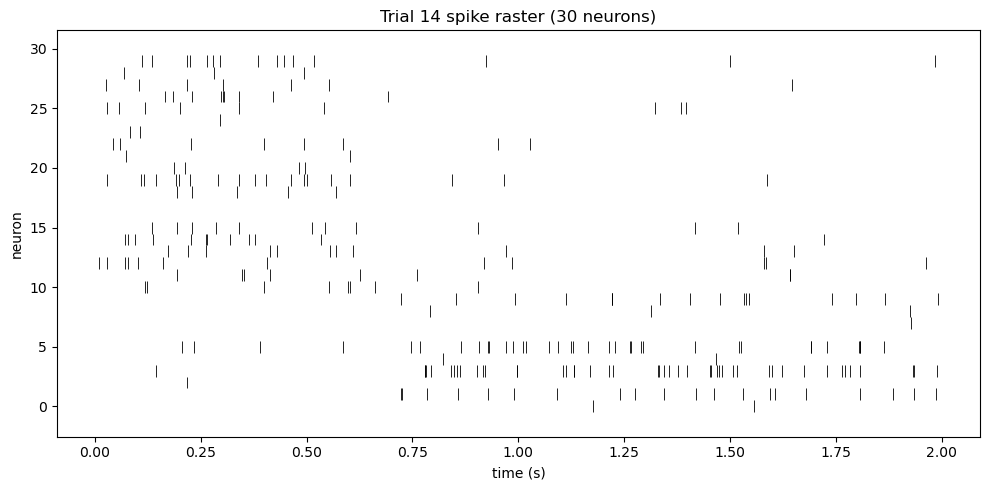

In [61]:
# just a basic raster: 

trial = 14 
df_t = df.filter(pl.col('trial')== trial)
n_neurons = df_t['neuron'].max() # do this rather than len(df_t['neuron']) to avoid out of range error. 
spikes = [[] for _ in range(n_neurons)]
for neuron, t in zip(df_t['neuron'].to_list(), df_t['spk_time'].to_list()):
    # undo the 1 indexing from matlab
    spikes[neuron -1].append(t)
plt.figure(figsize=(10,5))
plt.eventplot(spikes, colors = 'black', linewidths=0.6)
plt.xlabel('time (s)')
plt.ylabel('neuron')
plt.title(f'Trial {trial} spike raster ({n_neurons} neurons)')
plt.tight_layout()
plt.show()

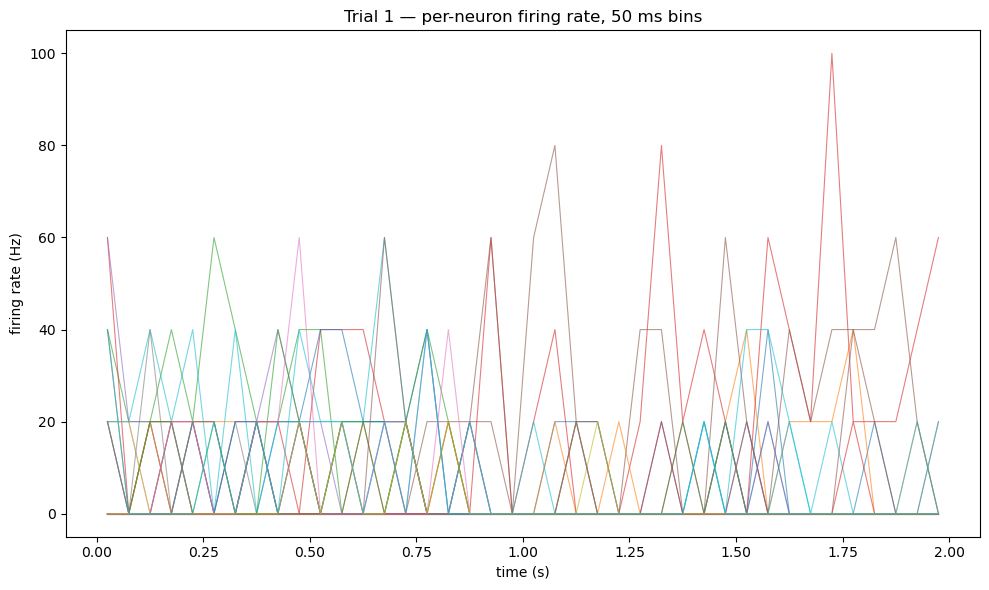

In [64]:
import matplotlib.pyplot as plt
import polars as pl

trial = 1
bin_size = 0.05          # 50 ms — per-neuron rates are sparse, so a wider bin reads better
n_neurons = df['neuron'].max()    # full unit set, 1-indexed

t1 = df.filter(pl.col('trial') == trial)
n_bins = int(t1['spk_time'].max() / bin_size) + 1

# counts[neuron_row][bin] -> spike count
counts = [[0] * n_bins for _ in range(n_neurons)]
for neuron, t in zip(t1['neuron'].to_list(), t1['spk_time'].to_list()):
    counts[neuron - 1][int(t / bin_size)] += 1

centers = [(b + 0.5) * bin_size for b in range(n_bins)]   # bin centers, seconds

plt.figure(figsize=(10, 6))
for n in range(n_neurons):
    rate = [c / bin_size for c in counts[n]]              # count → Hz (per neuron)
    plt.plot(centers, rate, linewidth=0.8, alpha=0.6)

plt.xlabel('time (s)')
plt.ylabel('firing rate (Hz)')
plt.title(f'Trial {trial} — per-neuron firing rate, {int(bin_size*1000)} ms bins')
plt.tight_layout()
plt.show()

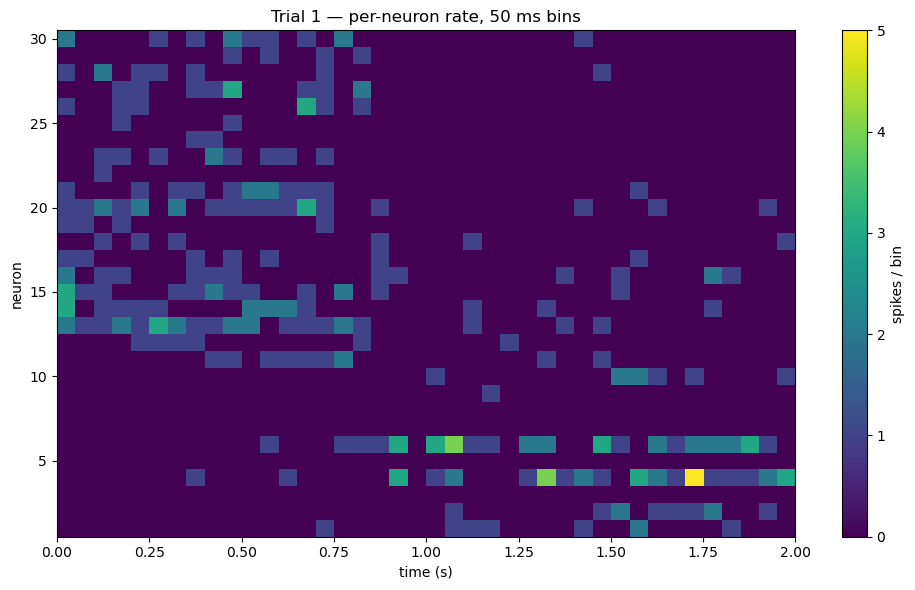

In [ ]:
# from the above fig, we now do spikes per bin-- tryna see some sort of structure? there clearly is 
# maybe I'm loading this in wrong from Paul, but I'm struggling to see it....
# ah well. 
plt.figure(figsize=(10, 6))
plt.imshow(counts, aspect='auto', origin='lower',
           extent=[0, n_bins * bin_size, 0.5, n_neurons + 0.5],
           interpolation='nearest', cmap='viridis')
plt.colorbar(label='spikes / bin')
plt.xlabel('time (s)'); plt.ylabel('neuron')
plt.title(f'Trial {trial} — per-neuron rate, {int(bin_size*1000)} ms bins')
plt.tight_layout(); plt.show()